# Week 6: End-to-End Data Analysis Project

## Project Title
Titanic Passenger Survival Analysis and Prediction

## Introduction

This project presents an end-to-end data analysis of Titanic passenger data. The analysis combines data exploration, data cleaning, statistical analysis, visualization, and machine learning techniques developed throughout the previous weeks.

The main objective is to understand the factors associated with passenger survival and build a machine learning model to predict survival outcomes. The project uses passenger characteristics such as passenger class, gender, age, family information, fare, and port of embarkation.

The analysis follows a structured workflow starting from data loading and validation, followed by data preparation, exploratory analysis, statistical analysis, visualization, predictive modeling, and model evaluation.

The final results are used to identify important patterns in passenger survival and provide meaningful conclusions based on the analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/PRAKRUTHI/OneDrive/Desktop/DA_Internship/sql/train.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Shape: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows: 0

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 4. Data Cleaning

The dataset contains missing values in Age, Cabin, and Embarked. No duplicate rows were found. The missing values are handled before further analysis and modeling to ensure the dataset is suitable for the end-to-end workflow.

In [4]:
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
df_clean = df.copy()

# Fill missing Age values with median
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

# Fill missing Embarked values with mode
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# Remove Cabin because most values are missing
df_clean = df_clean.drop(columns=["Cabin"])

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [6]:
print("Dataset shape after cleaning:", df_clean.shape)
df_clean.head()

Dataset shape after cleaning: (891, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


### Cleaning Result

The missing Age values were replaced using the median age. The two missing Embarked values were replaced using the most frequent embarkation port. The Cabin column was removed because a large proportion of its values were missing. No duplicate records were present in the dataset.

## 5. Data Visualization

Data visualization is used to identify patterns and relationships in the Titanic dataset. The analysis focuses on survival rates across passenger class, gender, age group, family size, embarkation point, and travel status.

Survival Rate by Passenger Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


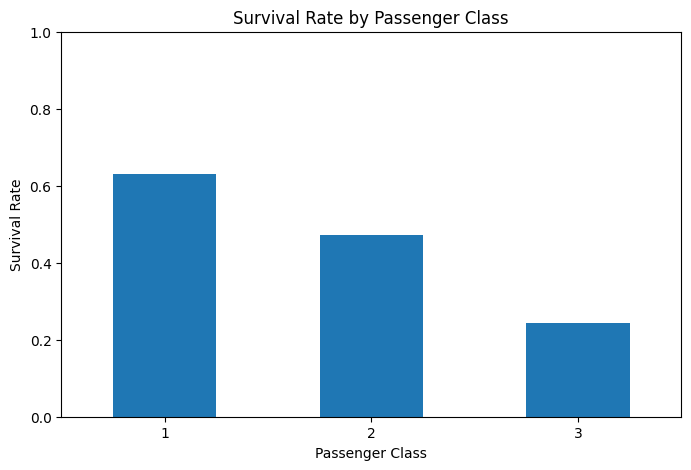

In [7]:
# Survival Rate by Passenger Class

survival_by_class = df_clean.groupby("Pclass")["Survived"].mean()

print("Survival Rate by Passenger Class:")
print(survival_by_class)

plt.figure(figsize=(8, 5))
survival_by_class.plot(kind="bar")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

### Interpretation

The survival rate differs across passenger classes. First-class passengers had the highest survival rate, while third-class passengers had the lowest survival rate. This indicates a relationship between passenger class and survival.

Survival Rate by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


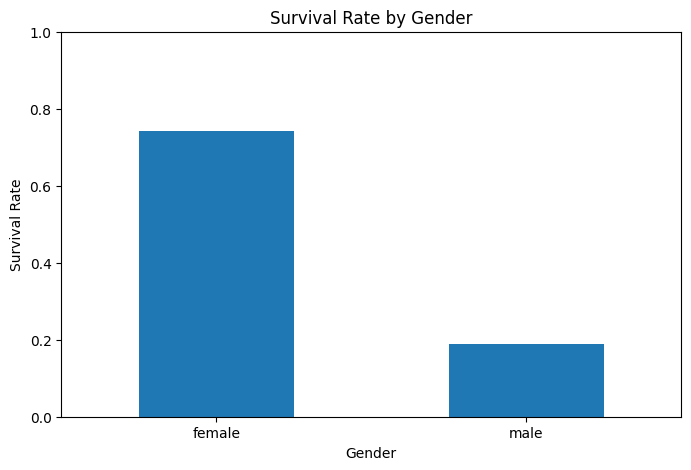

In [9]:
# Survival Rate by Gender

survival_by_gender = df_clean.groupby("Sex")["Survived"].mean()

print("Survival Rate by Gender:")
print(survival_by_gender)

plt.figure(figsize=(8, 5))
survival_by_gender.plot(kind="bar")

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

### Interpretation

The survival rate differs between male and female passengers. Female passengers had a higher survival rate than male passengers in this dataset.

## 6. Survival Rate by Age Group

Age groups are created to compare survival rates across different age ranges.

Survival Rate by Age Group:
Age_Group
Child          0.579710
Teenager       0.428571
Adult          0.353271
Middle-aged    0.400000
Senior         0.227273
Name: Survived, dtype: float64


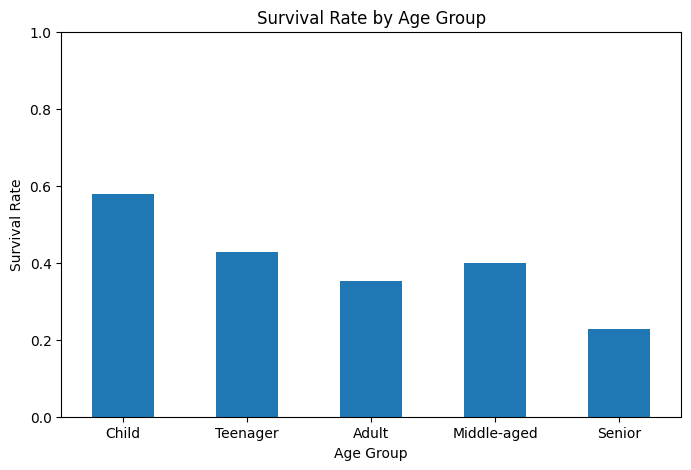

In [10]:
df_clean["Age_Group"] = pd.cut(
    df_clean["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teenager", "Adult", "Middle-aged", "Senior"]
)

survival_by_age = df_clean.groupby("Age_Group", observed=True)["Survived"].mean()

print("Survival Rate by Age Group:")
print(survival_by_age)

plt.figure(figsize=(8, 5))
survival_by_age.plot(kind="bar")

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## 7. Survival Rate by Embarked Port

This analysis compares passenger survival rates based on their port of embarkation.

Survival Rate by Embarked Port:
Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


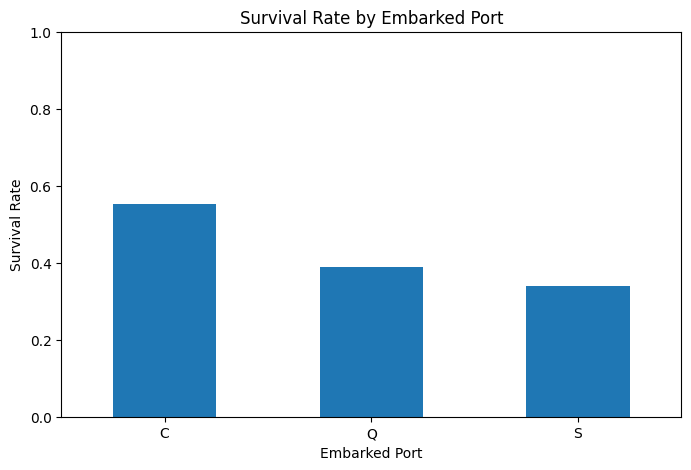

In [11]:
survival_by_embarked = df_clean.groupby("Embarked")["Survived"].mean()

print("Survival Rate by Embarked Port:")
print(survival_by_embarked)

plt.figure(figsize=(8, 5))
survival_by_embarked.plot(kind="bar")

plt.title("Survival Rate by Embarked Port")
plt.xlabel("Embarked Port")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## 8. Survival Rate by Family Size

Family size is calculated using the number of siblings, spouses, parents, and children travelling with each passenger.

Survival Rate by Family Size:
Family_Size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


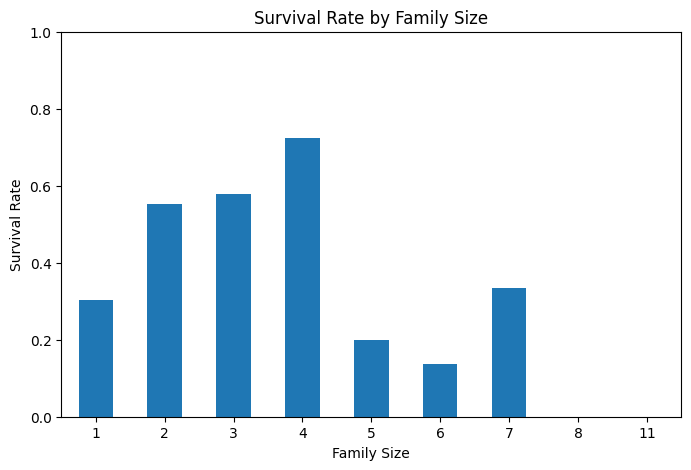

In [12]:
df_clean["Family_Size"] = df_clean["SibSp"] + df_clean["Parch"] + 1

survival_by_family = df_clean.groupby("Family_Size")["Survived"].mean()

print("Survival Rate by Family Size:")
print(survival_by_family)

plt.figure(figsize=(8, 5))
survival_by_family.plot(kind="bar")

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## 9. Survival Rate by Travel Status

Travel status is classified based on the passenger's family size to compare survival patterns between passengers travelling alone and passengers travelling with family.

Survival Rate by Travel Status:
Travel_Status
Alone          0.303538
With Family    0.505650
Name: Survived, dtype: float64


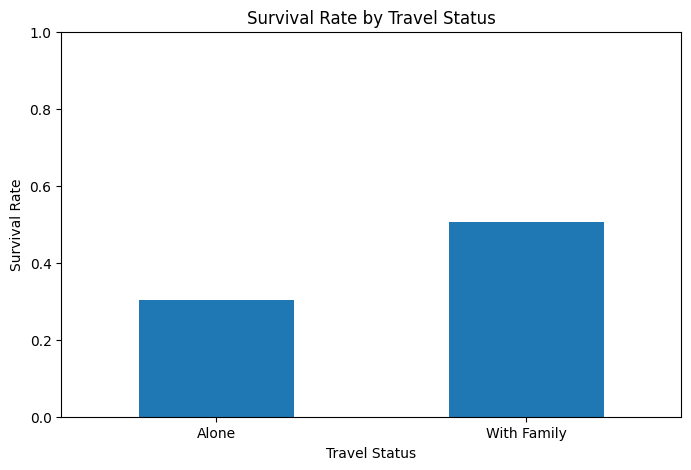

In [13]:
df_clean["Travel_Status"] = np.where(
    df_clean["Family_Size"] == 1,
    "Alone",
    "With Family"
)

survival_by_travel = df_clean.groupby("Travel_Status")["Survived"].mean()

print("Survival Rate by Travel Status:")
print(survival_by_travel)

plt.figure(figsize=(8, 5))
survival_by_travel.plot(kind="bar")

plt.title("Survival Rate by Travel Status")
plt.xlabel("Travel Status")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## 10. Survival Rate by Title

The passenger title is extracted from the Name column. Titles such as Mr, Miss, Mrs, and Master help identify differences in survival rates across passenger groups.

Survival Rate by Title:
Title
Master    0.575000
Miss      0.702703
Mr        0.156673
Mrs       0.793651
Other     0.347826
Name: Survived, dtype: float64


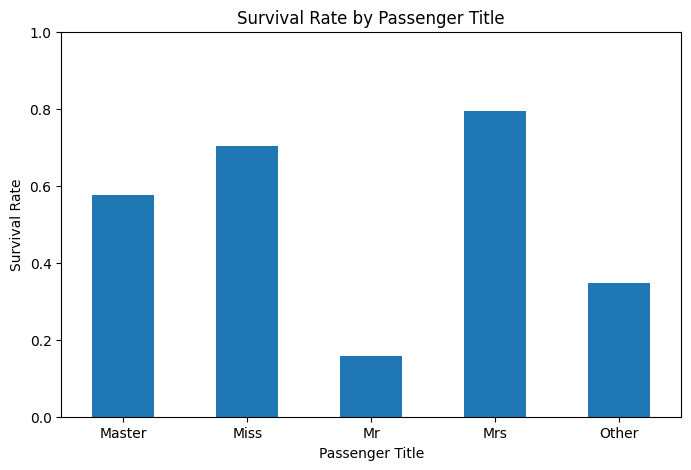

In [14]:
# Extract passenger title
df_clean["Title"] = df_clean["Name"].str.extract(r",\s*([^.]*)\.")

# Group uncommon titles
title_mapping = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
}

df_clean["Title"] = df_clean["Title"].replace(title_mapping)

common_titles = ["Mr", "Miss", "Mrs", "Master"]

df_clean["Title"] = np.where(
    df_clean["Title"].isin(common_titles),
    df_clean["Title"],
    "Other"
)

survival_by_title = df_clean.groupby("Title")["Survived"].mean()

print("Survival Rate by Title:")
print(survival_by_title)

plt.figure(figsize=(8, 5))
survival_by_title.plot(kind="bar")

plt.title("Survival Rate by Passenger Title")
plt.xlabel("Passenger Title")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

### Interpretation

Survival rates differ across passenger titles. Titles such as Mrs, Miss, and Master represent groups with higher survival rates compared with Mr. This indicates that passenger demographic characteristics were associated with survival outcomes.

## 11. Correlation Analysis

Correlation analysis is used to examine the relationships between numerical variables in the dataset. The correlation matrix helps identify variables that have positive or negative relationships with survival.

Correlation Matrix:
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.034212 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.064910 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.339898  0.083081  0.018443   
Age             0.034212 -0.064910 -0.339898  1.000000 -0.233296 -0.172482   
SibSp          -0.057527 -0.035322  0.083081 -0.233296  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.172482  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096688  0.159651  0.216225   
Family_Size    -0.040143  0.016639  0.065997 -0.245619  0.890712  0.783111   

                 Fare  Family_Size  
PassengerId  0.012658    -0.040143  
Survived     0.257307     0.016639  
Pclass      -0.549500     0.065997  
Age          0.096688    -0.245619  
SibSp        0.159651     0.890712  
Parch        0.216225     0.783111  
Fare         1.000

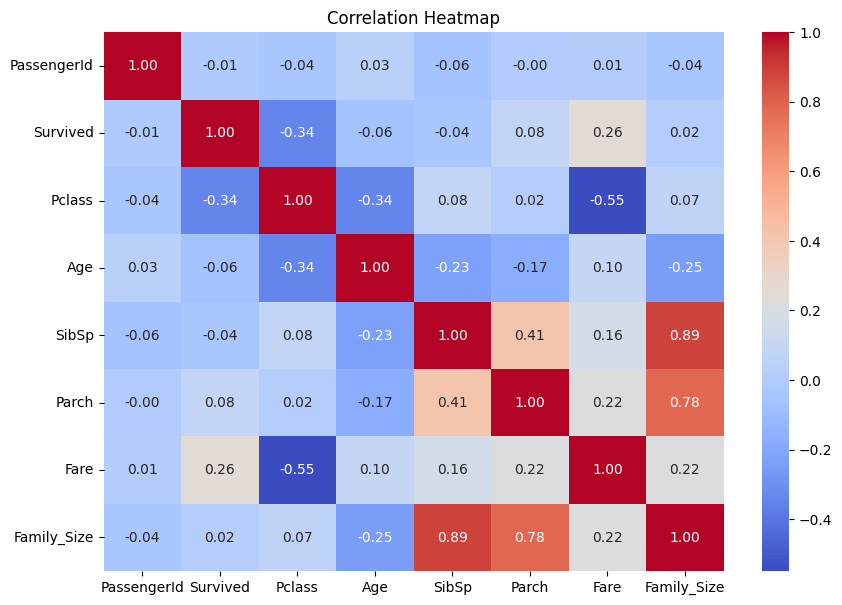

In [15]:
# Correlation matrix
correlation = df_clean.select_dtypes(include=np.number).corr()

print("Correlation Matrix:")
print(correlation)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Interpretation

The correlation analysis shows that Pclass has the strongest negative correlation with Survived at approximately -0.34. Fare has a positive correlation with Survived at approximately 0.26. Age, SibSp, Parch, and Family_Size show weak correlations with survival.

The results suggest that passenger class and fare have stronger linear relationships with survival than the other numerical variables. Correlation indicates association and does not establish causation.

## 12. Machine Learning Prediction

Machine learning models are used to predict passenger survival based on selected passenger characteristics. The target variable is Survived.

The selected features are Pclass, Sex, Age, SibSp, Parch, Fare, and Embarked. PassengerId, Name, Ticket, and Cabin are excluded from the prediction model.

Three classification algorithms are evaluated:
1. Logistic Regression
2. Decision Tree
3. Random Forest

The models are compared using Accuracy, Precision, Recall, and F1-score.

In [16]:
# Machine Learning Prediction

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Select features
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

X = df_clean[features]
y = df_clean["Survived"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (712, 7)
Testing data shape: (179, 7)


In [17]:
# Identify numerical and categorical columns

numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Sex", "Embarked"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [18]:
# Define models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

print("Model Performance Comparison:")
print(results_df)

Model Performance Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409
1        Decision Tree  0.826816   0.806452  0.724638  0.763359
2        Random Forest  0.821229   0.813559  0.695652  0.750000


In [19]:
# Display results as percentages

results_display = results_df.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    results_display[column] = (
        results_display[column] * 100
    ).round(2)

results_display

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,80.45,79.31,66.67,72.44
1,Decision Tree,82.68,80.65,72.46,76.34
2,Random Forest,82.12,81.36,69.57,75.00


## 13. Best Model and Confusion Matrix

Based on the model comparison, the Decision Tree model achieved the highest accuracy of 82.68% and the highest F1 score of 76.34%.

Therefore, the Decision Tree model is selected as the best-performing model for this analysis.

A confusion matrix is used to evaluate the classification results by comparing the actual survival status with the predicted survival status.

Confusion Matrix:
[[98 12]
 [19 50]]


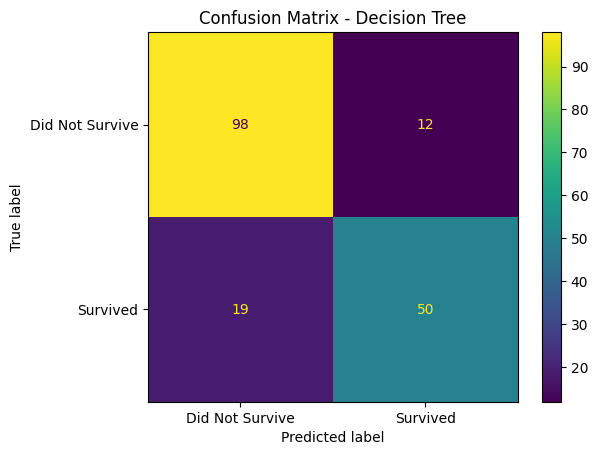

In [20]:
# Best Model: Decision Tree

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create Decision Tree pipeline
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Train the best model
best_model.fit(X_train, y_train)

# Make predictions
y_pred_best = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"]
)

disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

### Interpretation

The confusion matrix shows the number of passengers correctly and incorrectly classified by the Decision Tree model.

The model correctly identifies passengers who survived and passengers who did not survive. The off-diagonal values represent incorrect predictions.

The Decision Tree achieved an accuracy of 82.68%, making it the best-performing model among the three models tested.

Feature importance shows which variables contributed most to the Decision Tree's survival predictions.

Feature Importance:
cat__Sex_female    0.316638
num__Age           0.277142
num__Fare          0.228086
num__Pclass        0.110247
cat__Embarked_S    0.027544
num__SibSp         0.020872
num__Parch         0.012056
cat__Embarked_Q    0.005458
cat__Embarked_C    0.001958
cat__Sex_male      0.000000
dtype: float64


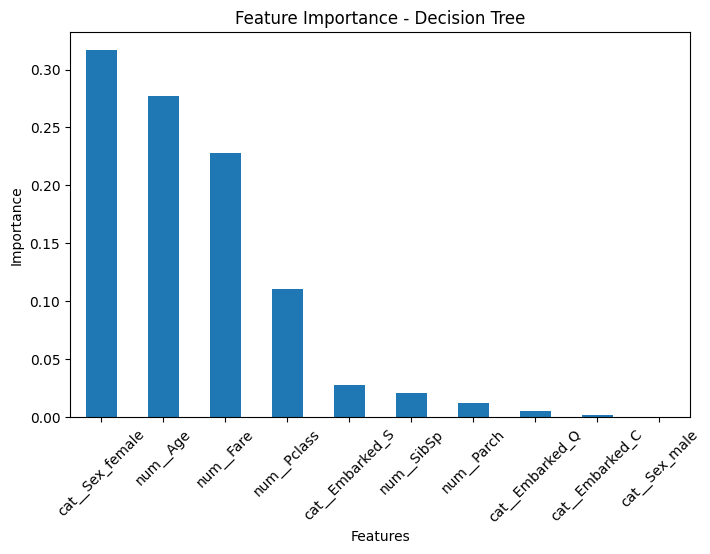

In [22]:
# Feature importance from Decision Tree

best_model = models["Decision Tree"]

# Create Decision Tree pipeline
best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

# Train the pipeline
best_pipeline.fit(X_train, y_train)

# Get feature names after preprocessing
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importance = pd.Series(
    best_pipeline.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("Feature Importance:")
print(importance)

# Plot
plt.figure(figsize=(8, 5))
importance.plot(kind="bar")

plt.title("Feature Importance - Decision Tree")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

### Interpretation

The feature importance analysis shows which features had the greatest influence on the Decision Tree's predictions.

Sex_female was the most important feature, with an importance of 31.66%. Age was the second most important feature at 27.71%, followed by Fare at 22.81%.

Pclass also contributed to the model, with an importance of 11.02%. Embarked, SibSp, and Parch had smaller contributions.

Overall, Sex, Age, Fare, and Pclass were the main features used by the Decision Tree to predict passenger survival.

## 14. Project Conclusion

This project analyzed the Titanic dataset through a complete data analysis workflow, including data cleaning, exploratory data analysis, visualization, correlation analysis, and machine learning.

The analysis showed that passenger class, gender, age, fare, family size, travel status, and passenger title were associated with survival outcomes.

Among the machine learning models tested, the Decision Tree achieved the highest overall accuracy of 82.68% and an F1 Score of 76.34%.

The feature importance analysis showed that Sex_female, Age, Fare, and Pclass were the most influential features for the Decision Tree model.

The project demonstrates how Python, Pandas, Matplotlib, and Scikit-learn can be used to clean data, identify patterns, visualize findings, and build predictive models.

## 15. Save Cleaned Dataset

The cleaned Titanic dataset is saved as a CSV file for future analysis and reference.

In [25]:
# Save cleaned dataset

df_clean.to_csv("Titanic_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Titanic Data Analysis and Survival Prediction

## Project Overview

This project analyzes the Titanic dataset to identify factors associated with passenger survival and builds machine learning models to predict survival outcomes.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

## Analysis Performed

- Data cleaning and missing value handling
- Exploratory data analysis
- Survival rate analysis
- Data visualization
- Feature engineering
- Correlation analysis
- Machine learning model training
- Model performance comparison
- Confusion matrix analysis
- Feature importance analysis

## Machine Learning Models

- Logistic Regression
- Decision Tree
- Random Forest

## Best Model

The Decision Tree achieved the highest accuracy among the tested models.

Accuracy: 82.68%

Precision: 80.65%

Recall: 72.46%

F1 Score: 76.34%

## Key Findings

- Female passengers had a higher survival rate than male passengers.
- First-class passengers had a higher survival rate than second and third-class passengers.
- Younger passengers, especially children, showed higher survival rates.
- Passengers travelling with family had a higher survival rate than passengers travelling alone.
- Sex, Age, Fare, and Pclass were the most important features for the Decision Tree model.

## Conclusion

The project demonstrates an end-to-end data analysis and machine learning workflow using the Titanic dataset. It shows how data cleaning, visualization, statistical analysis, feature engineering, and machine learning can be combined to generate useful insights and predictions.